# Assignment 1: Data Parsing, Cleansing and Integration
## Task 1 and 2
#### Student Name: Ngo Trong Nhan
#### Student ID: s4196976

Date: 2026-04-14

Version: 1.0

Environment: Python 3 and Jupyter notebook

Libraries used: please include the main libraries you used in your assignment, e.g.,:
* pandas
* re
* numpy

## Introduction
Brief information of this assessment, e.g., what problems were this assessment tackling, what problems were discovered in the data while you were parsing or cleansing it, and the approaches you chose to handle them, etc.

<span style="color: red"> Note that this is a sample notebook only. You will need to fill in the proper markdown and code blocks. You might also want to make necessary changes to the structure to meet your own needs. Note also that any generic comments written in this notebook are to be removed and replace with your own words.</span>

## Importing libraries 

Please follow the [README.md](https://github.com/DatacollectorVN/RMIT-Advanced-Programming-for-Data-Science) to install the dependecies packages

In [1]:
import xml.etree.ElementTree as ET
import pandas as pd
import numpy as np
import re
import seaborn as sns
import matplotlib.pyplot as plt
from dataclasses import dataclass, asdict
from datetime import datetime
from typing import Optional
from IPython.display import display
import copy
from rapidfuzz import process, fuzz # rapidfuzz is a library for fuzzy matching that is used in the audit_spelling function


# Helper

The helper function / class

In [2]:
_DATE_FMT = "%Y%m%dT%H%M%S"


def _to_int(value: str) -> Optional[int]:
    """Parse a string to int, or None if parsing fails.

    Args:
        value: Raw text (e.g. from XML element).

    Returns:
        Integer value, or ``None`` if ``value`` is not a valid integer.
    """
    try:
        return int(value)
    except (ValueError, TypeError):
        return None


def _to_float(value: str) -> Optional[float]:
    """Parse a string to float, or None if parsing fails.

    Args:
        value: Raw text (e.g. salary field).

    Returns:
        Float value, or ``None`` if ``value`` is not a valid number.
    """
    try:
        return float(value)
    except (ValueError, TypeError):
        return None


def _to_datetime(value: str) -> Optional[datetime]:
    """Parse ``YYYYMMDDTHHMMSS`` into a naive datetime.

    Args:
        value: Date-time string from XML job attributes.

    Returns:
        ``datetime`` on success, or ``None`` if format is invalid.
    """
    try:
        return datetime.strptime(value, _DATE_FMT)
    except (ValueError, TypeError):
        return None


@dataclass
class JobRecord:
    """
    Represents a single job listing record with fields matching the required schema.
    """
    Id:           Optional[int]
    Title:        str
    Location:     str
    Company:      str
    ContractType: str
    ContractTime: str
    Category:     str
    Salary:       Optional[float]
    OpenDate:     Optional[datetime]
    CloseDate:    Optional[datetime]
    SourceName:   str

    def to_dict(self) -> dict:
        """Serialize this record to a plain ``dict`` suitable for ``pd.DataFrame``.

        Args:
            None (instance method).

        Returns:
            Dictionary mapping field names to values (``dataclasses.asdict``).
        """
        return asdict(self)


class XMLJobProcessor:
    """
    Parses an XML job-listing file and exposes its records as a list of JobRecord instances.
    """

    def __init__(self, xml_file: str):
        """Load XML from disk and build the in-memory job record list.

        Args:
            xml_file: Path to the XML file (e.g. ``data/data_4.xml``).

        Returns:
            None (initialises ``__root``, ``__sources``, ``__job_records``).
        """
        self.__root: ET.Element = ET.parse(xml_file).getroot()
        self.__sources: list[ET.Element] = self.__root.findall("Source")
        self.__job_records: list[JobRecord] = self._parse_records()

    def _parse_records(self) -> list[JobRecord]:
        """Walk all ``Source`` / ``Job`` nodes and produce ``JobRecord`` instances.

        Args:
            None (uses ``self.__sources``).

        Returns:
            List of ``JobRecord``, one per ``<Job>`` element.
        """
        return [
            JobRecord(
                Id=           _to_int(job.findtext("Id", "").strip()),
                Title=        job.findtext("Title", "").strip(),
                Location=     job.findtext("Location", "").strip(),
                Company=      job.findtext("Company", "").strip(),
                ContractType= job.findtext("ContractType", "").strip(),
                ContractTime= job.findtext("ContractTime", "").strip(),
                Category=     job.findtext("Category", "").strip(),
                Salary=       _to_float(job.findtext("Salary", "").strip()),
                OpenDate=     _to_datetime(job.attrib.get("OpenDate", "")),
                CloseDate=    _to_datetime(job.attrib.get("CloseDate", "")),
                SourceName=   source.attrib.get("Name", ""),
            )
            for source in self.__sources
            for job in source.findall("Job")
        ]

    @property
    def job_records(self) -> list[JobRecord]:
        """All parsed job records (read-only access to internal list).

        Args:
            None.

        Returns:
            List of ``JobRecord`` instances.
        """
        return self.__job_records

    def __str__(self) -> str:
        """Short debug string: source count and record count.

        Args:
            None.

        Returns:
            Human-readable summary string.
        """
        return f"XMLJobProcessor(sources={len(self.__sources)}, job_records={len(self.__job_records)})"

    def __len__(self) -> int:
        """Number of job records.

        Args:
            None.

        Returns:
            Integer count of ``JobRecord`` entries.
        """
        return len(self.__job_records)

    def get_data_frame(self) -> pd.DataFrame:
        """Materialise all records as a pandas ``DataFrame``.

        Args:
            None.

        Returns:
            ``pd.DataFrame`` with one row per job and schema columns from ``JobRecord``.
        """
        return pd.DataFrame([r.to_dict() for r in self.__job_records])


In [3]:
class JobAuditor:
    """
    Audit job data for missing values and record errors.
    """
    # Error list schema columns
    __ERROR_COLS = ['indexOfdf', 'Id', 'ColumnName', 'Original', 'Modified', 'ErrorType', 'Fixing']
    
    # Columns whose missing/empty value is replaced with 'non-specified'
    __NON_SPECIFIED_COLS = ['Title', 'Location', 'Company', 'SourceName',
                      'ContractType', 'ContractTime', 'Category']

    __VALID_CONTRACT_TYPE = {'full_time', 'part_time', 'non-specified'}
    __VALID_CONTRACT_TIME = {'permanent', 'contract', 'non-specified'}
    __VALID_CATEGORY = {
        'IT Jobs',
        'Healthcare & Nursing Jobs',
        'Engineering Jobs',
        'Accounting & Finance Jobs',
        'Sales Jobs',
        'Hospitality & Catering Jobs',
        'Teaching Jobs',
        'PR, Advertising & Marketing Jobs',
    }

    __MIN_YEAR = 1990
    __MAX_YEAR = 2035

    def __init__(self, df: pd.DataFrame):
        """Attach a working copy of the job table and an empty error log.

        Args:
            df: Parsed job data (typically from ``XMLJobProcessor.get_data_frame()``).

        Returns:
            None (sets ``self.df`` and ``self.errors``).
        """
        self.df: pd.DataFrame = df.copy() # Deep copy of the dataframe to avoid modifying the original dataframe
        self.errors: list[dict] = []

    def copy(self) -> "JobAuditor":
        """Clone this auditor so changes do not affect the original.

        Args:
            None.

        Returns:
            New ``JobAuditor`` with deep-copied ``df`` and deep-copied ``errors`` list.
        """
        
        other = object.__new__(self.__class__)
        other.df = self.df.copy(deep=True)
        other.errors = copy.deepcopy(self.errors)
        return other
    
    def apply_log_transformation(self, columns: object = "Salary", log1p: bool = True) -> None:
        """
        Apply a log transform to numeric columns in place to reduce right skew.

        Uses ``numpy.log1p`` by default (``log(1+x)``), which is defined for ``x >= 0``
        (including zero). Non-positive values become NaN. Missing values stay missing.
        Set ``log1p=False`` for natural ``log(x)`` (requires strictly positive values).

        Args:
            columns: Single column name or iterable of names to transform.
            log1p: If True, use ``log1p``; if False, use natural ``log`` (positive values only).

        Returns:
            None (updates ``self.df`` in place; raises ``KeyError`` for unknown columns).
        """
        cols: list[str] = [columns] if isinstance(columns, str) else list(columns)
        for col in cols:
            if col not in self.df.columns:
                raise KeyError(f"Unknown column: {col!r}")
            x = pd.to_numeric(self.df[col], errors="coerce")
            if log1p:
                self.df[col] = np.log1p(np.where(x >= 0, x, np.nan))
            else:
                self.df[col] = np.log(np.where(x > 0, x, np.nan))
    
    def _is_blank(self, series: pd.Series) -> pd.Series:
        """Return a boolean mask for missing / blank values.

        For **object**, **string**, and **categorical** columns: null, empty/whitespace
        strings, and placeholders ``'-'``, ``'N/A'``, ``'n/a'`` (after strip) count as blank.

        For all other dtypes (numeric, datetime, etc.): only ``.isna()`` is used —
        no string coercion or placeholder rules.

        Args:
            series: Column or vector to test.

        Returns:
            Boolean ``pd.Series`` aligned with ``series`` index.
        """
        na_mask: pd.Series = series.isna()
        text_like: bool = (
            pd.api.types.is_object_dtype(series)
            or pd.api.types.is_string_dtype(series)
            or isinstance(series.dtype, pd.CategoricalDtype)
        )
        if not text_like:
            return na_mask
        st: pd.Series = series.astype(str).str.strip()
        empty: pd.Series = st == ''
        placeholder: pd.Series = st.isin(['-', 'N/A', 'n/a']) | (st.str.lower() == 'n/a')
        return na_mask | empty | placeholder

    def get_miss_values_df(self) -> pd.DataFrame:
        """
        Return missing-value counts for every column.

        Rules (delegated to ``_is_blank`` per column dtype):
        - text-like columns (object / string / category): NaN, empty/whitespace,
          and ``'-'`` / ``'N/A'`` / ``'n/a'`` placeholders
        - other columns: NaN/NaT only

        Args:
            None (uses ``self.df``).

        Returns:
            ``pd.DataFrame`` with columns ``ColumnName``, ``MissingCount``, ``MissingPct``,
            sorted by missing count descending.
        """
        rows = []
        for col in self.df.columns:
            series = self.df[col]
            missing_mask = self._is_blank(series)
            rows.append(
                {
                    'ColumnName': col,
                    'MissingCount': int(missing_mask.sum()),
                    'MissingPct': round(float(missing_mask.mean() * 100), 4),
                }
            )
        return pd.DataFrame(rows).sort_values('MissingCount', ascending=False).reset_index(drop=True)

    def _record_error(
        self,
        index_of_df,
        job_id,
        column_name: str,
        original,
        modified,
        error_type: str,
        fixing: str,
    ) -> None:
        """Append one row to the assignment error list schema.

        Args:
            index_of_df: Row label in ``self.df`` (pandas index).
            job_id: Job ``Id`` for this row.
            column_name: Affected column(s), as a string (may be comma-separated).
            original: Value before fix; use ``None`` when not applicable.
            modified: Value after fix; may equal ``original`` if only logged.
            error_type: Category, e.g. ``Missing Value``, ``Outlier``.
            fixing: Human-readable description of the change.

        Returns:
            None (appends to ``self.errors``).
        """
        self.errors.append(
            {
                'indexOfdf':  index_of_df,
                'Id':         job_id,
                'ColumnName': column_name,
                'Original':   original,
                'Modified':   modified,
                'ErrorType':  error_type,
                'Fixing':     fixing,
            }
        )

    @classmethod
    def _canonical_contract_type(cls, raw) -> Optional[str]:
        """Map common variants/typos to a valid ``ContractType``, or None if unknown.

        Args:
            raw: Cell value from ``ContractType`` (may be NaN or string).

        Returns:
            Canonical string in ``__VALID_CONTRACT_TYPE``, or ``None`` if no mapping applies.
        """
        if pd.isna(raw):
            return None
        s = str(raw).strip()
        if s in cls.__VALID_CONTRACT_TYPE:
            return s
        if s in ('-', 'N/A') or s.lower() == 'n/a':
            return 'non-specified'
        lo = ' '.join(s.lower().replace('-', ' ').replace('_', ' ').split())
        compact = lo.replace(' ', '')
        if compact == 'fulltime' or lo == 'full time':
            return 'full_time'
        if compact == 'parttime' or lo == 'part time':
            return 'part_time'
        if compact in ('nonspecified',) or lo == 'non specified':
            return 'non-specified'
        if lo.replace(' ', '_') in ('full_time', 'part_time', 'non_specified'):
            return lo.replace(' ', '_').replace('non_specified', 'non-specified')
        for v in cls.__VALID_CONTRACT_TYPE:
            if s.lower() == v.lower():
                return v
        return None

    @classmethod
    def _canonical_contract_time(cls, raw) -> Optional[str]:
        """Map common variants/typos to a valid ``ContractTime``, or None if unknown.

        Args:
            raw: Cell value from ``ContractTime`` (may be NaN or string).

        Returns:
            Canonical string in ``__VALID_CONTRACT_TIME``, or ``None`` if no mapping applies.
        """
        if pd.isna(raw):
            return None
        s = str(raw).strip()
        if s in cls.__VALID_CONTRACT_TIME:
            return s
        if s in ('-', 'N/A') or s.lower() == 'n/a':
            return 'non-specified'
        lo = ' '.join(s.lower().replace('-', ' ').replace('_', ' ').split())
        if lo in ('perm', 'permanent'):
            return 'permanent'
        if lo == 'contract':
            return 'contract'
        if lo.replace(' ', '') == 'nonspecified' or lo == 'non specified':
            return 'non-specified'
        for v in cls.__VALID_CONTRACT_TIME:
            if s.lower() == v.lower():
                return v
        return None

    @classmethod
    def _canonical_category(cls, raw) -> Optional[str]:
        """Return an allowed ``Category`` string if recognized (exact, case, or alias).

        Args:
            raw: Cell value from ``Category`` (may be NaN or string).

        Returns:
            One of ``__VALID_CATEGORY`` when mappable, else ``None``.
        """
        if pd.isna(raw):
            return None
        s = ' '.join(str(raw).strip().split())
        if s in cls.__VALID_CATEGORY:
            return s
        for v in cls.__VALID_CATEGORY:
            if s.lower() == v.lower():
                return v
        aliases = {
            'it job': 'IT Jobs',
            'it jobs': 'IT Jobs',
            'engineering job': 'Engineering Jobs',
            'engineering jobs': 'Engineering Jobs',
            'sales job': 'Sales Jobs',
            'sales jobs': 'Sales Jobs',
            'teaching job': 'Teaching Jobs',
            'teaching jobs': 'Teaching Jobs',
            'healthcare & nursing job': 'Healthcare & Nursing Jobs',
            'healthcare & nursing jobs': 'Healthcare & Nursing Jobs',
            'accounting & finance job': 'Accounting & Finance Jobs',
            'accounting & finance jobs': 'Accounting & Finance Jobs',
            'hospitality & catering job': 'Hospitality & Catering Jobs',
            'hospitality & catering jobs': 'Hospitality & Catering Jobs',
            'pr, advertising & marketing job': 'PR, Advertising & Marketing Jobs',
            'pr, advertising & marketing jobs': 'PR, Advertising & Marketing Jobs',
        }
        if s.lower() in aliases:
            return aliases[s.lower()]
        return None

    @staticmethod
    def _smart_title(s: str) -> str:
        """
        Title-case a location string while preserving:
        - ALL-CAPS abbreviations up to 5 chars (UK, USA, NHS …)
        - Apostrophe-words correctly: "king's" → "King's" (not "King'S")
        - Hyphenated parts: "newcastle-under-lyme" → "Newcastle-Under-Lyme"

        Args:
            s: Raw location text.

        Returns:
            Title-cased string (never mutates input).
        """
        def cap_word(w: str) -> str:
            if w.isupper() and len(w) <= 5:  # abbreviation
                return w
            # capitalise first letter only, keep rest as-is (preserve inner case like McDonald)
            return w[0].upper() + w[1:].lower() if w else w
        # split on whitespace and hyphens, keeping delimiters
        parts = re.split(r'([ \t\-]+)', s.strip())
        return ''.join(cap_word(p) if re.search(r'[a-zA-Z]', p) else p for p in parts)

    @staticmethod
    def _build_location_cache(
        locations: pd.Series,
        freq_threshold: int = 5,
        score_threshold: float = 90.0,
    ) -> dict:
        """
        Build a {raw_value: corrected_value} cache using rapidfuzz.

        Strategy:
        1. Title-case all values.
        2. Treat locations that appear >= freq_threshold times as the reference set.
        3. For any unique value whose title-cased form is NOT in the reference set,
           fuzzy-match (WRatio >= score_threshold) against the reference set.
        4. Only store entries where something actually changed.

        Args:
            locations: ``pd.Series`` of location strings (typically ``self.df['Location']``).
            freq_threshold: Minimum count for a title-cased value to enter the reference set.
            score_threshold: Minimum ``rapidfuzz`` WRatio for accepting a fuzzy match.

        Returns:
            Dict mapping each **original** unique raw value to its corrected string
            (only keys where correction or casing differs from raw).
        """
        counts = locations.value_counts()
        reference: list[str] = sorted({
            JobAuditor._smart_title(str(v))
            for v, c in counts.items()
            if c >= freq_threshold and pd.notna(v) and str(v).strip()
        })
        ref_set = set(reference)

        cache: dict = {}
        for raw in counts.index:
            if pd.isna(raw) or not str(raw).strip():
                continue
            tc = JobAuditor._smart_title(str(raw))
            if tc in ref_set:
                if tc != raw:
                    cache[raw] = tc   # casing fix only
                continue
            # fuzzy-match against the reference list
            result = process.extractOne(tc, reference, scorer=fuzz.WRatio)
            if result is not None:
                match, score, _ = result
                if score >= score_threshold and match != tc:
                    cache[raw] = match
                elif tc != raw:
                    cache[raw] = tc
            elif tc != raw:
                cache[raw] = tc
        return cache

    def audit_spelling(self, verbose: bool = False, **kwargs) -> None:
        """
        Detect and fix misspellings / typos across four columns. Each fix is
        logged in ``self.errors`` with ErrorType='Misspelling / Typo'.

        ContractType
        ------------
        Uses a hand-crafted lookup table (``_canonical_contract_type``).
        Placeholder tokens ('N/A', '-') → 'non-specified'.
        Common variants (e.g. 'fulltime', 'Full_Time', 'full time') → 'full_time'.
        Case-insensitive match against the three valid values as a final fallback.

        ContractTime
        ------------
        Same lookup-table approach (``_canonical_contract_time``).
        Placeholder tokens → 'non-specified'.
        Abbreviations ('perm') and trailing-space variants → 'permanent'.

        Category
        --------
        Uses a lookup table (``_canonical_category``) that first tries an exact
        match, then case-insensitive, then a curated alias map
        (e.g. 'it job' → 'IT Jobs'). If a value still cannot be mapped,
        it is flagged in the error list and printed when verbose=True;
        the integrity audit will later replace it with 'non-specified'.

        Location
        --------
        Two-step normalization, computed once per unique value then applied
        via an O(1) cache lookup per row:
        1. ``_smart_title`` — title-cases each word while preserving ALL-CAPS
           abbreviations (UK, USA …) and apostrophe-words (King's Lynn).
        2. ``_build_location_cache`` — treats locations appearing >= 5 times as
           a trusted reference set; uses ``rapidfuzz.WRatio >= 90`` to fuzzy-match
           rare/suspicious values against that set (e.g. 'Londen' → 'London',
           'Manchaster' → 'Manchester').

        SourceName is intentionally skipped.

        Args:
            verbose: If True, print invalid-category lines and a total issue count.
            **kwargs: Reserved for future options (ignored today).

        Returns:
            None (updates ``self.df`` and appends to ``self.errors``).
        """
        n_before: int = len(self.errors)

        # Pre-compute Location corrections once per unique value (fast with rapidfuzz).
        loc_correction_cache: dict = self._build_location_cache(self.df['Location'])

        for tup in self.df.itertuples(index=True):
            idx = tup.Index
            job_id = getattr(tup, 'Id')

            # --- ContractType ---
            ct_cur = getattr(tup, 'ContractType')
            ct_new = self._canonical_contract_type(ct_cur)
            if ct_new is not None and ct_new != ct_cur:
                self._record_error(
                    idx, job_id, 'ContractType', ct_cur, ct_new,
                    'Misspelling / Typo',
                    f"ContractType spelling/normalization → {ct_new!r}",
                )
                self.df.at[idx, 'ContractType'] = ct_new

            # --- ContractTime ---
            cw_cur = getattr(tup, 'ContractTime')
            cw_new = self._canonical_contract_time(cw_cur)
            if cw_new is not None and cw_new != cw_cur:
                self._record_error(
                    idx, job_id, 'ContractTime', cw_cur, cw_new,
                    'Misspelling / Typo',
                    f"ContractTime spelling/normalization → {cw_new!r}",
                )
                self.df.at[idx, 'ContractTime'] = cw_new

            # --- Category ---
            cat_cur = getattr(tup, 'Category')
            if not (pd.isna(cat_cur) or str(cat_cur).strip() == ''):
                cat_new = self._canonical_category(cat_cur)
                if cat_new is not None:
                    if cat_new != cat_cur:
                        self._record_error(
                            idx, job_id, 'Category', cat_cur, cat_new,
                            'Misspelling / Typo',
                            f"Category spelling/normalization → {cat_new!r}",
                        )
                        self.df.at[idx, 'Category'] = cat_new
                else:
                    s = ' '.join(str(cat_cur).strip().split())
                    if s not in self.__VALID_CATEGORY and not any(
                        s.lower() == v.lower() for v in self.__VALID_CATEGORY
                    ):
                        self._record_error(
                            idx, job_id, 'Category', cat_cur, cat_cur,
                            'Misspelling / Typo',
                            'Category not in allowed set (not auto-corrected); see audit_integrity',
                        )
                        if verbose:
                            print(
                                f"[audit_spelling] invalid Category — index={idx} Id={job_id!r} value={cat_cur!r}"
                            )

            # --- Location ---
            loc_cur = getattr(tup, 'Location')
            loc_new = loc_correction_cache.get(loc_cur)
            if loc_new is not None and loc_new != loc_cur:
                self._record_error(
                    idx, job_id, 'Location', loc_cur, loc_new,
                    'Misspelling / Typo',
                    f"Location spelling/casing corrected: {loc_cur!r} → {loc_new!r}",
                )
                self.df.at[idx, 'Location'] = loc_new

        if verbose:
            print(f"[audit_spelling]: {len(self.errors) - n_before} issues recorded")

    def _salary_outlier_mask_iqr(self, k: float = 1.5, verbose: bool = False, **kwargs):
        """
        Tukey IQR fences: flag Salary outside [Q1-k*IQR, Q3+k*IQR], then winsorize
        to the fence values, log each change in self.errors, return the outlier mask.
        Ref: https://online.stat.psu.edu/stat200/lesson/3/3.2

        Args:
            k: Tukey fence multiplier (default 1.5).
            verbose: If True, print how many outlier rows were logged.
            **kwargs: Reserved.

        Returns:
            Boolean ``pd.Series`` mask (True where salary was an outlier and adjusted).
        """
        s: pd.Series = pd.to_numeric(self.df['Salary'], errors='coerce')
        valid: pd.Series = s.dropna()
        mask: pd.Series = pd.Series(False, index=self.df.index)
        if len(valid) < 4:
            return mask
        q1: float; q3: float; iqr: float; lo: float; hi: float
        q1, q3 = valid.quantile(0.25), valid.quantile(0.75)
        iqr = q3 - q1
        if iqr == 0 or np.isnan(iqr):
            return mask
        lo, hi = float(q1 - k * iqr), float(q3 + k * iqr)
        mask = s.notna() & ((s < lo) | (s > hi))
        if not mask.any():
            return mask
        orig: pd.Series = self.df.loc[mask, 'Salary'].astype(float)
        new_vals: pd.Series = np.where(orig < lo, lo, hi).astype(float)
        new_vals = np.round(new_vals, 2)
        self.df.loc[mask, 'Salary'] = new_vals
        n_before: int = len(self.errors)
        for tup in self.df[mask].itertuples(index=True):
            idx: int = tup.Index
            o: float = float(orig.loc[idx])
            m: float = float(self.df.at[idx, 'Salary'])
            self._record_error(
                idx,
                getattr(tup, 'Id'),
                'Salary',
                o,
                m,
                'Outlier',
                f'Salary outlier (IQR k={k}) winsorized to fence [{lo:.2f}, {hi:.2f}]',
            )
        
        if verbose:
            n_added: int = len(self.errors) - n_before
            print(
                f"[_salary_outlier_mask_iqr]: {n_added} issues"
            )

    def _salary_outlier_mask_zscore(self, z_thresh: float = 3.0, verbose: bool = False, **kwargs):
        """
        Z-score on non-null Salary: |x-mu|/sigma > z_thresh, then clip to
        [mu - z_thresh*sigma, mu + z_thresh*sigma], log changes, return mask.

        Args:
            z_thresh: Absolute z-score above which values are clipped.
            verbose: If True, print how many outlier rows were logged.
            **kwargs: Reserved.

        Returns:
            Boolean ``pd.Series`` mask (True where salary exceeded ``z_thresh`` and was clipped).
        """
        s: pd.Series = pd.to_numeric(self.df['Salary'], errors='coerce')
        valid: pd.Series = s.dropna()
        mask: pd.Series = pd.Series(False, index=self.df.index)
        if len(valid) < 2:
            return mask
        mu = float(valid.mean())
        sigma = float(valid.std(ddof=0))
        if sigma == 0 or np.isnan(sigma):
            return mask
        z: pd.Series = (s - mu).abs() / sigma
        mask: pd.Series = s.notna() & (z > z_thresh)
        if not mask.any():
            return mask
        
        lo: float; hi: float
        lo, hi = mu - z_thresh * sigma, mu + z_thresh * sigma
        orig: pd.Series = self.df.loc[mask, 'Salary'].astype(float)
        new_vals: pd.Series = np.where(orig < lo, lo, hi).astype(float)
        new_vals = np.round(new_vals, 2)
        self.df.loc[mask, 'Salary'] = new_vals
        n_before: int = len(self.errors)
        for tup in self.df[mask].itertuples(index=True):
            idx: int = tup.Index
            o: float = float(orig.loc[idx])
            m = float(self.df.at[idx, 'Salary'])
            self._record_error(
                idx,
                getattr(tup, 'Id'),
                'Salary',
                o,
                m,
                'Outlier',
                f'Salary outlier (|z|>{z_thresh}) clipped to [{lo:.2f}, {hi:.2f}]',
            )
        n_added: int = len(self.errors) - n_before
        if verbose:
            print(
                f"[_salary_outlier_mask_zscore]: {n_added} issues"
            )

    def salary_outlier_mask(self, method: str = 'iqr', **kwargs):
        """Dispatch salary outlier handling to IQR or z-score implementation.

        Args:
            method: ``'iqr'`` or ``'zscore'``.
            **kwargs: Passed through to ``_salary_outlier_mask_iqr`` or ``_salary_outlier_mask_zscore``.

        Returns:
            None (delegates; underlying methods return a boolean mask but this wrapper
            does not return it).
        """
        if method == 'iqr':
            self._salary_outlier_mask_iqr(**kwargs)
        elif method == 'zscore':
            self._salary_outlier_mask_zscore(**kwargs)
        else:
            raise ValueError("method must be 'iqr' or 'zscore'")

    def _date_outlier_mask(
        self,
        column: str,
        min_year: int = 1990,
        max_year: int = 2035,
        **kwargs
    ) -> pd.Series:
        """
        Years outside [min_year, max_year] are clamped to that range and logged.
        NaT is left unchanged (missing-value path).

        Args:
            column: Name of datetime column (``OpenDate`` or ``CloseDate``).
            min_year: Lower bound year (inclusive).
            max_year: Upper bound year (inclusive).
            **kwargs: Reserved.

        Returns:
            Boolean ``pd.Series`` mask (True where the date year was out of range and clamped).
        """
        dt = pd.to_datetime(self.df[column], errors='coerce')
        ok = dt.notna()
        y = dt.dt.year
        mask = ok & ((y < min_year) | (y > max_year))
        if not mask.any():
            return mask
        orig_vals = dt[mask].copy()
        too_low = mask & (y < min_year)
        too_high = mask & (y > max_year)
        clamp_lo = pd.Timestamp(year=min_year, month=1, day=1)
        clamp_hi = pd.Timestamp(year=max_year, month=12, day=31, hour=23, minute=59, second=59)
        self.df.loc[too_low, column] = clamp_lo
        self.df.loc[too_high, column] = clamp_hi
        n_before = len(self.errors)
        for tup in self.df[mask].itertuples(index=True):
            idx = tup.Index
            o = orig_vals.loc[idx]
            m = self.df.at[idx, column]
            self._record_error(
                idx,
                getattr(tup, 'Id'),
                column,
                o,
                m,
                'Outlier',
                f'Date year outside [{min_year}, {max_year}]; clamped to range bounds',
            )
        n_added = len(self.errors) - n_before
        print(
            f"[_date_outlier_mask]: {n_added} issues"
        )
        return mask
    
    def _impute_non_specified_columns(self, **kwargs):
        """Replace null/blank string fields with ``'non-specified'`` and log each change.

        Args:
            **kwargs: Reserved.

        Returns:
            None (updates ``self.df`` and ``self.errors``).
        """
        for col in self.__NON_SPECIFIED_COLS:
            mask = self._is_blank(self.df[col])
            # Use itertuples give the better performance than iterrows.
            # Ref: https://stackoverflow.com/questions/24870953/does-pandas-iterrows-have-performance-issues/24871316#24871316
            for tup in self.df[mask].itertuples(index=True):
                self.errors.append(
                    {
                        'indexOfdf':  tup.Index,
                        'Id':         getattr(tup, 'Id'),
                        'ColumnName': col,
                        'Original':   getattr(tup, col),
                        'Modified':   'non-specified',
                        'ErrorType':  'Missing Value',
                        'Fixing':     f"Null/empty '{col}' replaced with 'non-specified'",
                    }
                )
            self.df.loc[mask, col] = 'non-specified'
        
    def _impute_smart_salary(self, verbose: bool = False, **kwargs):
        """
        Impute missing Salary using hierarchical group medians:
        1) Category + ContractType + Location + Company
        2) Category + ContractType + Location
        3) Category + ContractType
        4) Category
        5) Global median fallback

        Args:
            verbose: If True, print total rows with missing salary processed.
            **kwargs: Reserved.

        Returns:
            None (fills ``Salary`` and appends to ``self.errors``).
        """
        group_levels: list[list[str]] = [
            ['Category', 'ContractType', 'Location', 'Company'],
            ['Category', 'ContractType', 'Location'],
            ['Category', 'ContractType'],
            ['Category'],
        ]

        salary_num = pd.to_numeric(self.df['Salary'], errors='coerce')
        salary_mask = salary_num.isna()
        if not salary_mask.any():
            return

        fill_values: pd.Series = pd.Series(np.nan, index=self.df.index)
        fill_level: pd.Series = pd.Series('', index=self.df.index, dtype='object')

        for keys in group_levels:
            need_fill: pd.Series = salary_mask & fill_values.isna()
            if not need_fill.any():
                break
            group_median: pd.Series = self.df.assign(SalaryNum=salary_num).groupby(keys)['SalaryNum'].transform('median')
            can_fill: pd.Series = need_fill & group_median.notna()
            fill_values.loc[can_fill] = group_median.loc[can_fill]
            fill_level.loc[can_fill] = 'median by ' + '+'.join(keys)

        need_fill: pd.Series = salary_mask & fill_values.isna()
        if need_fill.any():
            global_median = salary_num.median()
            fill_values.loc[need_fill] = global_median
            fill_level.loc[need_fill] = 'global median'

        fill_values = fill_values.round(2)

        for tup in self.df[salary_mask].itertuples(index=True):
            idx = tup.Index
            imputed = float(fill_values.loc[idx]) if pd.notna(fill_values.loc[idx]) else None
            method = fill_level.loc[idx]
            self._record_error(
                idx,
                getattr(tup, 'Id'),
                'Salary',
                getattr(tup, 'Salary'),
                imputed,
                'Missing Value',
                f"Null Salary imputed with {method}",
            )

        self.df.loc[salary_mask, 'Salary'] = fill_values.loc[salary_mask]

        if verbose:
            print(f"[_impute_smart_salary]: {int(salary_mask.sum())} issues")

    def _impute_opendate(self, verbose: bool = False, **kwargs) -> None:
        """
        Impute missing OpenDate using CloseDate minus the median listing duration
        (CloseDate - OpenDate) within the same ContractType and ContractTime.
        Fallback: global median duration where both dates exist.

        Args:
            verbose: If True, print skip/reason messages.
            **kwargs: Reserved.

        Returns:
            None (writes ``OpenDate`` and appends to ``self.errors``).
        """
        open_dt: pd.Series = pd.to_datetime(self.df['OpenDate'], errors='coerce')
        close_dt: pd.Series = pd.to_datetime(self.df['CloseDate'], errors='coerce')
        # Align grouping keys with missing-value rules (blank/NaN -> non-specified) for consistent medians
        g_ct: pd.Series = self.df['ContractType'].copy()
        g_ct.loc[self._is_blank(g_ct)] = 'non-specified'
        g_cw: pd.Series = self.df['ContractTime'].copy()
        g_cw.loc[self._is_blank(g_cw)] = 'non-specified'
        valid_both: pd.Series = open_dt.notna() & close_dt.notna()
        if not valid_both.any():
            if verbose:
                print("[_impute_opendate]: no rows with both OpenDate and CloseDate; skip")
            return

        delta: pd.Series = (close_dt - open_dt).loc[valid_both]
        temp_df: pd.DataFrame = pd.DataFrame(
            {'ContractType': g_ct.loc[valid_both], 'ContractTime': g_cw.loc[valid_both]}
        )
        temp_df['__delta'] = delta.values
        med_by_group: pd.Series = temp_df.groupby(['ContractType', 'ContractTime'], dropna=False)['__delta'].median()
        global_med_delta: float = temp_df['__delta'].median()

        need_mask: pd.Series = open_dt.isna() & close_dt.notna()
        if not need_mask.any():
            if verbose:
                print("[_impute_opendate]: 0 rows need imputation")
            return

        if pd.isna(global_med_delta):
            if verbose:
                print("[_impute_opendate]: cannot compute median delta; skip")
            return

        need_df: pd.DataFrame = self.df.loc[need_mask, ['Id']].copy()
        need_df['ContractType'] = g_ct.loc[need_df.index]
        need_df['ContractTime'] = g_cw.loc[need_df.index]
        need_df['_close'] = close_dt.loc[need_df.index]
        _need_idx: pd.Index = need_df.index.copy()
        need_df: pd.DataFrame = need_df.merge(
            med_by_group.rename('med_delta').reset_index(),
            on=['ContractType', 'ContractTime'],
            how='left',
        )
        need_df.index = _need_idx
        need_df['imputed_from_group'] = need_df['med_delta'].notna()
        need_df['med_delta'] = need_df['med_delta'].fillna(global_med_delta)
        need_df['new_open'] = need_df['_close'] - need_df['med_delta']

        for tup in need_df.itertuples(index=True):
            idx = tup.Index
            used = (
                'group median (ContractType+ContractTime)'
                if tup.imputed_from_group
                else 'global median (fallback)'
            )
            self._record_error(
                idx,
                getattr(tup, 'Id'),
                'OpenDate',
                None,
                tup.new_open,
                'Missing Value',
                f"OpenDate imputed as CloseDate minus median(CloseDate-OpenDate) ({used})",
            )

        # Assign with a Series (not .values) so index alignment is guaranteed
        self.df.loc[need_df.index, 'OpenDate'] = need_df['new_open']

        if verbose:
            print(f"[_impute_opendate]: {int(need_mask.sum())} issues")

    def audit_missing_values(self, verbose: bool = False, **kwargs):
        """Run non-specified imputation, salary imputation, and OpenDate imputation.

        Args:
            verbose: If True, print total new error-list rows added.
            **kwargs: Passed to sub-steps.

        Returns:
            None.
        """
        n_before: int = len(self.errors)
        self._impute_non_specified_columns(**kwargs)
        self._impute_smart_salary(verbose=verbose, **kwargs)
        self._impute_opendate(verbose=verbose, **kwargs)

        if verbose:
            n_added: int = len(self.errors) - n_before
            print(
                f"[audit_missing_values]: {n_added} issues"
            )

    def audit_outlier_values(self, outlier_method: str = 'iqr', **kwargs):
        """Run salary outlier handling (IQR or z-score) and year clamping for Open/Close dates.

        Args:
            outlier_method: ``'iqr'`` or ``'zscore'`` for salary.
            **kwargs: Optional ``min_year`` / ``max_year`` for ``_date_outlier_mask``.

        Returns:
            None.
        """
        self.salary_outlier_mask(outlier_method, **kwargs)
        y0: int = kwargs.get('min_year', self.__MIN_YEAR)
        y1: int = kwargs.get('max_year', self.__MAX_YEAR)
        self._date_outlier_mask('OpenDate', min_year=y0, max_year=y1)
        self._date_outlier_mask('CloseDate', min_year=y0, max_year=y1)

    @classmethod
    def _is_valid_id_8_digits(cls, value) -> bool:
        """Return True if ``value`` is a finite integer with exactly 8 decimal digits.

        Args:
            value: Scalar from ``Id`` column.

        Returns:
            ``True`` if valid 8-digit id, else ``False``.
        """
        if pd.isna(value):
            return False
        try:
            n = float(value)
        except (ValueError, TypeError):
            return False
        if not n.is_integer():
            return False
        n_int = int(n)
        return len(str(abs(n_int))) == 8

    def _audit_id(self):
        """Flag invalid ``Id`` (not 8-digit integer) and duplicate ``Id`` values.

        Args:
            None.

        Returns:
            None (appends to ``self.errors``; does not drop rows).
        """
        id_num: pd.Series = pd.to_numeric(self.df['Id'], errors='coerce')

        id_len_valid_mask: pd.Series = self.df['Id'].apply(self._is_valid_id_8_digits)
        bad_id_mask: pd.Series = id_num.isna() | (id_num % 1 != 0) | (~id_len_valid_mask)
        for tup in self.df[bad_id_mask].itertuples(index=True):
            self._record_error(
                tup.Index,
                getattr(tup, 'Id'),
                'Id',
                getattr(tup, 'Id'),
                getattr(tup, 'Id'),
                'Violation of Integrity Constraint',
                'Id must be a unique 8-digit integer (value not changed)',
            )
        
        dup_mask: pd.Series = self.df['Id'].duplicated(keep=False)
        for tup in self.df[dup_mask].itertuples(index=True):
            self._record_error(
                tup.Index,
                getattr(tup, 'Id'),
                'Id',
                getattr(tup, 'Id'),
                getattr(tup, 'Id'),
                'Violation of Integrity Constraint',
                'Duplicate Id detected (value not changed)',
            )
    
    def _audit_contract_type(self):
        """Replace ``ContractType`` not in the allowed set with ``'non-specified'``.

        Args:
            None.

        Returns:
            None.
        """
        ct_mask: pd.Series = ~self.df['ContractType'].isin(self.__VALID_CONTRACT_TYPE)
        for tup in self.df[ct_mask].itertuples(index=True):
            self._record_error(
                tup.Index,
                getattr(tup, 'Id'),
                'ContractType',
                getattr(tup, 'ContractType'),
                'non-specified',
                'Violation of Integrity Constraint',
                "Invalid ContractType; replaced with 'non-specified'",
            )
        self.df.loc[ct_mask, 'ContractType'] = 'non-specified'

    def _audit_contract_time(self):
        """Replace ``ContractTime`` not in the allowed set with ``'non-specified'``.

        Args:
            None.

        Returns:
            None.
        """
        ctime_mask: pd.Series = ~self.df['ContractTime'].isin(self.__VALID_CONTRACT_TIME)
        for tup in self.df[ctime_mask].itertuples(index=True):
            self._record_error(
                tup.Index,
                getattr(tup, 'Id'),
                'ContractTime',
                getattr(tup, 'ContractTime'),
                'non-specified',
                'Violation of Integrity Constraint',
                "Invalid ContractTime; replaced with 'non-specified'",
            )
        self.df.loc[ctime_mask, 'ContractTime'] = 'non-specified'

    def _audit_category(self):
        """Replace ``Category`` not in the allowed set with ``'non-specified'``.

        Args:
            None.

        Returns:
            None.
        """
        cat_mask: pd.Series = ~self.df['Category'].isin(self.__VALID_CATEGORY)
        for tup in self.df[cat_mask].itertuples(index=True):
            self._record_error(
                tup.Index,
                getattr(tup, 'Id'),
                'Category',
                getattr(tup, 'Category'),
                'non-specified',
                'Violation of Integrity Constraint',
                "Invalid Category; replaced with 'non-specified'",
            )
        self.df.loc[cat_mask, 'Category'] = 'non-specified'

    def _audit_salary(self):
        """Log null salaries; round non-null ``Salary`` to two decimal places.

        Args:
            None.

        Returns:
            None.
        """
        sal_num: pd.Series = pd.to_numeric(self.df['Salary'], errors='coerce')
        sal_invalid_mask: pd.Series = sal_num.isna()
        for tup in self.df[sal_invalid_mask].itertuples(index=True):
            self._record_error(
                tup.Index,
                getattr(tup, 'Id'),
                'Salary',
                getattr(tup, 'Salary'),
                getattr(tup, 'Salary'),
                'Violation of Integrity Constraint',
                'Salary must be a valid non-null float',
            )
        
        # round to 2dp as required (log only changed values)
        rounded = sal_num.round(2)
        changed_mask = sal_num.notna() & ((sal_num - rounded).abs() > 0)
        for tup in self.df[changed_mask].itertuples(index=True):
            new_val = float(rounded.loc[tup.Index])
            self._record_error(
                tup.Index,
                getattr(tup, 'Id'),
                'Salary',
                float(getattr(tup, 'Salary')),
                new_val,
                'Violation of Integrity Constraint',
                'Salary rounded to 2 decimal places',
            )
        self.df.loc[sal_num.notna(), 'Salary'] = rounded[sal_num.notna()]
    
    def _audit_open_and_close_date(self):
        """Ensure ``CloseDate`` is strictly after ``OpenDate`` when both parse.

        Args:
            None.

        Returns:
            None (may bump ``CloseDate`` by one day).
        """
        open_dt: pd.Series = pd.to_datetime(self.df['OpenDate'], errors='coerce')
        close_dt: pd.Series = pd.to_datetime(self.df['CloseDate'], errors='coerce')

        both_valid: pd.Series = open_dt.notna() & close_dt.notna()
        bad_order: pd.Series = both_valid & (close_dt <= open_dt)
        for tup in self.df[bad_order].itertuples(index=True):
            self._record_error(
                tup.Index,
                getattr(tup, 'Id'),
                'OpenDate,CloseDate',
                f"OpenDate={getattr(tup, 'OpenDate')}, CloseDate={getattr(tup, 'CloseDate')}",
                f"OpenDate={getattr(tup, 'OpenDate')}, CloseDate={getattr(tup, 'OpenDate') + pd.Timedelta(days=1)}",
                'Violation of Integrity Constraint',
                'CloseDate must be after OpenDate; set CloseDate = OpenDate + 1 day',
            )
        self.df.loc[bad_order, 'CloseDate'] = open_dt[bad_order] + pd.Timedelta(days=1)
        
    def audit_integrity(self, verbose: bool = False, **kwargs):
        """Run all integrity checks: Id, contract fields, category, salary, date order.

        Args:
            verbose: If True, print count of new error rows.
            **kwargs: Reserved.

        Returns:
            None.
        """
        n_before: int = len(self.errors)
        # 1) Id: integer, 8 digits, unique
        self._audit_id()

        # 2) ContractType domain
        self._audit_contract_type()

        # 3) ContractTime domain
        self._audit_contract_time()

        # 4) Category domain
        self._audit_category()

        # 5) Salary: valid float and 2 decimal places
        self._audit_salary()

        # 6) Cross-column constraint: CloseDate > OpenDate
        self._audit_open_and_close_date()

        if verbose:
            n_added = len(self.errors) - n_before
            print(f"[audit_integrity]: {n_added} issues")

    def get_duplicate_df(
        self,
        near_dup_keys: list = ['Title', 'Company', 'OpenDate'],
        verbose: bool = False,
    ) -> pd.DataFrame:
        """
        Detect three categories of duplicates and return a summary DataFrame.

        1. **Exact-row duplicates** — all columns identical.
        2. **Duplicate Id** — same Id appears more than once (already in audit_integrity,
           included here as a standalone report).
        3. **Near-duplicates** — rows sharing the same composite key
           (default: Title + Company + OpenDate) but with different Id values.

        Args:
            near_dup_keys: Columns defining a near-duplicate key (default
                ``['Title', 'Company', 'OpenDate']``).
            verbose: If True, print duplicate index samples and a summary table.

        Returns:
            ``pd.DataFrame`` with columns ``DuplicateType``, ``Count``, ``Indices``
            (``Indices`` holds row labels involved in each duplicate class).
        """

        results: list[dict] = []

        # 1) Exact-row duplicates
        exact_mask: pd.Series = self.df.duplicated(keep=False)
        exact_indices: list = sorted(self.df.index[exact_mask].tolist())
        results.append({
            'DuplicateType': 'Exact row duplicate',
            'Count': int(exact_mask.sum()),
            'Indices': exact_indices,
        })
        if verbose and exact_indices:
            print(f"[get_duplicate_df] Exact-row duplicates ({len(exact_indices)} rows): {exact_indices[:10]}{'...' if len(exact_indices) > 10 else ''}")

        # 2) Duplicate Id
        id_dup_mask: pd.Series = self.df.duplicated(subset=['Id'], keep=False)
        id_dup_indices: list = sorted(self.df.index[id_dup_mask].tolist())
        results.append({
            'DuplicateType': 'Duplicate Id',
            'Count': int(id_dup_mask.sum()),
            'Indices': id_dup_indices,
        })
        if verbose and id_dup_indices:
            print(f"[get_duplicate_df] Duplicate Id ({len(id_dup_indices)} rows): {id_dup_indices[:10]}{'...' if len(id_dup_indices) > 10 else ''}")

        # 3) Near-duplicates (same key, but possibly different Id)
        valid_keys = [k for k in near_dup_keys if k in self.df.columns]
        near_dup_mask: pd.Series = self.df.duplicated(subset=valid_keys, keep=False)
        # Exclude rows that are already exact duplicates
        near_only_mask: pd.Series = near_dup_mask & ~exact_mask
        near_dup_indices: list = sorted(self.df.index[near_only_mask].tolist())
        results.append({
            'DuplicateType': f'Near-duplicate ({" + ".join(valid_keys)})',
            'Count': int(near_only_mask.sum()),
            'Indices': near_dup_indices,
        })
        if verbose and near_dup_indices:
            print(f"[get_duplicate_df] Near-duplicates ({len(near_dup_indices)} rows): {near_dup_indices[:10]}{'...' if len(near_dup_indices) > 10 else ''}")

        summary: pd.DataFrame = pd.DataFrame(results)
        if verbose:
            has_any = summary['Count'].sum() > 0
            if not has_any:
                print('[get_duplicate_df] No duplicates found.')
            else:
                print('[get_duplicate_df] Summary:')
                print(summary[['DuplicateType', 'Count']].to_string(index=False))
        return summary

    def audit_and_clean_data(self, **kwargs):
        """Full cleaning pipeline: missing values → spelling → integrity → outliers.

        Args:
            **kwargs: Forwarded to each audit step (e.g. ``verbose``, ``outlier_method``).

        Returns:
            None.
        """
        self.audit_missing_values(**kwargs)
        self.audit_spelling(**kwargs)
        self.audit_integrity(**kwargs)
        self.audit_outlier_values(**kwargs)
        

In [4]:
class Visualizer:
    """Helper for generating seaborn-based figures."""

    @staticmethod
    def visualize_distribution(data: pd.Series) -> plt.Figure:
        """Plot histogram+KDE and boxplot for a numeric series (e.g. salary).

        Args:
            data: Values to summarise (coerced with ``pd.to_numeric``; NaNs dropped).

        Returns:
            ``matplotlib.figure.Figure``; figure is closed so notebooks should ``display(fig)``.
        """
        data_filtered = pd.to_numeric(data, errors='coerce').dropna()

        sns.set_theme(style='whitegrid')
        fig, axes = plt.subplots(1, 2, figsize=(14, 5))

        sns.histplot(data_filtered, bins=60, kde=True, ax=axes[0], color='steelblue')
        axes[0].set_title('Salary Distribution (Histogram + KDE)')
        axes[0].set_xlabel('Salary')
        axes[0].set_ylabel('Count')

        sns.boxplot(x=data_filtered, ax=axes[1], color='lightcoral')
        axes[1].set_title('Salary Distribution (Boxplot)')
        axes[1].set_xlabel('Salary')

        plt.tight_layout()
        plt.close(fig)  # prevent Jupyter auto-display; caller can display(fig) when needed
        return fig


## Task 1. Parsing Data

### 1.1. Examining and loading data

The file `data_4.xml` is a structured XML file containing UK job listings aggregated from multiple job board sources.

**Structure overview:**

- The root element is `<Rows>`, which contains 107 `<Source>` child elements.
- Each `<Source>` element has a `Name` attribute identifying the originating job board (e.g., `gorkanajobs.co.uk`, `totaljobs.com`).
- Within each `<Source>`, there are one or more `<Job>` elements. Each `<Job>` carries two attributes:
  - `OpenDate` — the date the listing became active (format: `YYYYMMDDTHHMMSS`)
  - `CloseDate` — the date the listing expired (same format)
- Each `<Job>` element contains the following child elements, all wrapped in `CDATA` sections to allow special characters:

The file contains **50,753 job records** in total across all sources. Records are stored hierarchically — grouped first by source site, then by individual job posting.

In [5]:
XML_FILE = "data/data_4.xml"

job_processor: XMLJobProcessor = XMLJobProcessor(XML_FILE)
print(job_processor)
records: list[JobRecord] = job_processor.job_records
print(f"Total records: {len(records)}")
print(f"first job record: {records[0]}")

XMLJobProcessor(sources=107, job_records=50753)
Total records: 50753
first job record: JobRecord(Id=69793814, Title='PR Senior Account Executive  Consumer PR', Location='London', Company='Fresh Connect', ContractType='full_time', ContractTime='permanent', Category='PR, Advertising & Marketing Jobs', Salary=28500.0, OpenDate=datetime.datetime(2012, 6, 17, 12, 0), CloseDate=datetime.datetime(2012, 8, 16, 12, 0), SourceName='gorkanajobs.co.uk')


### 1.2 Parsing data into the required format

<span style="color: red"> You might have complex notebook structure in this section, please feel free to create your own notebook structure. </span>

In [6]:
# Code to parse data
df: pd.DataFrame = job_processor.get_data_frame()
df.info()
print()
df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50753 entries, 0 to 50752
Data columns (total 11 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   Id            50753 non-null  int64         
 1   Title         50753 non-null  object        
 2   Location      50753 non-null  object        
 3   Company       50753 non-null  object        
 4   ContractType  50753 non-null  object        
 5   ContractTime  50753 non-null  object        
 6   Category      50753 non-null  object        
 7   Salary        48373 non-null  float64       
 8   OpenDate      50752 non-null  datetime64[ns]
 9   CloseDate     50753 non-null  datetime64[ns]
 10  SourceName    50753 non-null  object        
dtypes: datetime64[ns](2), float64(1), int64(1), object(7)
memory usage: 4.3+ MB



,Id,Title,Location,Company,ContractType,ContractTime,Category,Salary,OpenDate,CloseDate,SourceName
0,69793814,PR Senior Account Executive Consumer PR,London,Fresh Connect,full_time,permanent,"PR, Advertising & Marketing Jobs",28500.0,2012-06-17 12:00:00,2012-08-16 12:00:00,gorkanajobs.co.uk
1,66796338,Press and Public Affairs Manager,London,Prospect Resourcing,full_time,permanent,"PR, Advertising & Marketing Jobs",45000.0,2013-02-19 00:00:00,2013-03-21 00:00:00,gorkanajobs.co.uk
2,69140453,Senior Account Executive Business / Enterprise,South East London,Unicorn Jobs,full_time,permanent,"PR, Advertising & Marketing Jobs",22000.0,2012-05-26 15:00:00,2012-07-25 15:00:00,gorkanajobs.co.uk
3,69585249,Digital Account Manager Leading Global Consum...,London,Hanson Search Ltd,full_time,permanent,"PR, Advertising & Marketing Jobs",40000.0,2012-06-20 00:00:00,2012-07-20 00:00:00,gorkanajobs.co.uk
4,71136184,Account Executive Leading PR Agency Consumer...,Central London,Reuben Sinclair,full_time,permanent,"PR, Advertising & Marketing Jobs",23500.0,2013-05-10 15:00:00,2013-06-09 15:00:00,gorkanajobs.co.uk


......

## Task 2. Auditing and cleansing the loaded data

Here, you should write your own code to audit data, identify data problems and to fix them. You are also required to record the errors found and fixings in an error list.

<span style="color: red"> You might have complex notebook structure in this section, please feel free to create your own notebook structure. </span>

### 2.1 Missing Values Audit

Check each column for `null` values and empty strings, record every issue in the error list, then apply the appropriate fix per the specification.

In [7]:
job_auditor = JobAuditor(df)

In [8]:
# Check duplication
df_summary: pd.DataFrame = job_auditor.get_duplicate_df(verbose=True, near_dup_keys=['Title', 'Location', 'Company', 'ContractTime', 'OpenDate', 'Salary', 'SourceName'])


[get_duplicate_df] Near-duplicates (6 rows): [27912, 27945, 45211, 45231, 50214, 50289]
[get_duplicate_df] Summary:
                                                                              DuplicateType  Count
                                                                        Exact row duplicate      0
                                                                               Duplicate Id      0
Near-duplicate (Title + Location + Company + ContractTime + OpenDate + Salary + SourceName)      6


In [9]:
# Check the duplicate rows
dup_idx: list = [27912, 27945, 45211, 45231, 50214, 50289]
job_auditor.df.loc[dup_idx]

,Id,Title,Location,Company,ContractType,ContractTime,Category,Salary,OpenDate,CloseDate,SourceName
27912,70141144,Paeds (OT),Cambridgeshire,Castlerock Recruitment Group,-,permanent,Healthcare & Nursing Jobs,28000.0,2013-11-11 12:00:00,2013-12-11 12:00:00,tntjobs.co.uk
27945,69063472,Paeds (OT),Cambridgeshire,Castlerock Recruitment Group,-,permanent,Healthcare & Nursing Jobs,28000.0,2013-11-11 12:00:00,2013-12-11 12:00:00,tntjobs.co.uk
45211,68379170,Associate Investment Consultants,Hampshire,Dimensions Specialist Recruitment,-,permanent,Accounting & Finance Jobs,45000.0,2013-01-23 12:00:00,2013-04-23 12:00:00,professionalpensionsjobs.com
45231,69063427,Associate Investment Consultants,Hampshire,Dimensions Specialist Recruitment,N/A,permanent,Accounting & Finance Jobs,45000.0,2013-01-23 12:00:00,2013-04-23 12:00:00,professionalpensionsjobs.com
50214,71293952,Senior Credit Strategy Manager Acquisitons SAS,London,Eurobase People,-,permanent,Accounting & Finance Jobs,52500.0,2013-05-22 15:00:00,2013-06-21 15:00:00,jobsinrisk.com
50289,69063457,Senior Credit Strategy Manager Acquisitons SAS,London,Eurobase People,-,permanent,Accounting & Finance Jobs,52500.0,2013-05-22 15:00:00,2013-06-21 15:00:00,jobsinrisk.com


In [10]:
# Remove the first occurrence of each near-duplicate pair
rows_to_drop: list = [27912, 45211, 50214]
job_auditor.df.drop(index=rows_to_drop, inplace=True)

job_auditor.df.reset_index(drop=True, inplace=True)

In [11]:
job_auditor.df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50750 entries, 0 to 50749
Data columns (total 11 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   Id            50750 non-null  int64         
 1   Title         50750 non-null  object        
 2   Location      50750 non-null  object        
 3   Company       50750 non-null  object        
 4   ContractType  50750 non-null  object        
 5   ContractTime  50750 non-null  object        
 6   Category      50750 non-null  object        
 7   Salary        48370 non-null  float64       
 8   OpenDate      50749 non-null  datetime64[ns]
 9   CloseDate     50750 non-null  datetime64[ns]
 10  SourceName    50750 non-null  object        
dtypes: datetime64[ns](2), float64(1), int64(1), object(7)
memory usage: 4.3+ MB


In [12]:
# Check the missing values and its percentage
job_auditor.get_miss_values_df()

,ColumnName,MissingCount,MissingPct
0,ContractType,38068,75.0108
1,ContractTime,14133,27.8483
2,Company,4949,9.7517
3,Salary,2380,4.6897
4,OpenDate,1,0.0020
5,Id,0,0.0000
6,Title,0,0.0000
7,Location,0,0.0000
8,Category,0,0.0000
9,CloseDate,0,0.0000


*My solution:*

`audit_missing_values` applies missing-value handling in **three ordered steps**. Each step appends rows to the shared error list (`self.errors`) whenever a value is imputed or replaced.

1. **`_impute_non_specified_columns`** — For `Title`, `Location`, `Company`, `SourceName`, `ContractType`, `ContractTime`, and `Category`, any **null** or **whitespace-only** string is replaced with **`non-specified`**. Every change is logged as a missing-value fix.

2. **`_impute_smart_salary`** — Rows with missing **Salary** are filled using **hierarchical group medians** (non-missing salaries only), trying in order: `Category + ContractType + Location + Company` → `Category + ContractType + Location` → `Category + ContractType` → `Category`. Any salary still missing after those steps gets the **global** salary median. Values are rounded to **two decimal places**, and each imputation is logged with the level used (e.g. `median by Category+ContractType` or `global median`).

3. **`_impute_opendate`** — For rows with **missing OpenDate** but a valid **CloseDate**, **OpenDate** is set to **CloseDate minus** the median listing length **(CloseDate − OpenDate)**. That median is computed **per (`ContractType`, `ContractTime`)** (with blank contract fields treated as **`non-specified`** so keys line up with the rest of the pipeline). If no group median exists, the **global** median duration is used. Each imputation is logged. After merging group medians, the row index is **restored** so updates apply to the correct dataframe rows.

Finally, if `verbose=True`, the method prints how many new error-list entries were added in total for this audit.


In [13]:
job_auditor.audit_missing_values(verbose=True)

[_impute_smart_salary]: 2380 issues
[_impute_opendate]: 1 issues
[audit_missing_values]: 59531 issues


In [14]:
# Check the missing values and its percentage after audit
job_auditor.get_miss_values_df()

,ColumnName,MissingCount,MissingPct
0,Id,0,0.0
1,Title,0,0.0
2,Location,0,0.0
3,Company,0,0.0
4,ContractType,0,0.0
5,ContractTime,0,0.0
6,Category,0,0.0
7,Salary,0,0.0
8,OpenDate,0,0.0
9,CloseDate,0,0.0


In [15]:
job_auditor.df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50750 entries, 0 to 50749
Data columns (total 11 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   Id            50750 non-null  int64         
 1   Title         50750 non-null  object        
 2   Location      50750 non-null  object        
 3   Company       50750 non-null  object        
 4   ContractType  50750 non-null  object        
 5   ContractTime  50750 non-null  object        
 6   Category      50750 non-null  object        
 7   Salary        50750 non-null  float64       
 8   OpenDate      50750 non-null  datetime64[ns]
 9   CloseDate     50750 non-null  datetime64[ns]
 10  SourceName    50750 non-null  object        
dtypes: datetime64[ns](2), float64(1), int64(1), object(7)
memory usage: 4.3+ MB


### 2.2 Salary Distribution Visualization (Seaborn)

Visualize salary distribution after auditing/cleansing to inspect skewness and outliers.

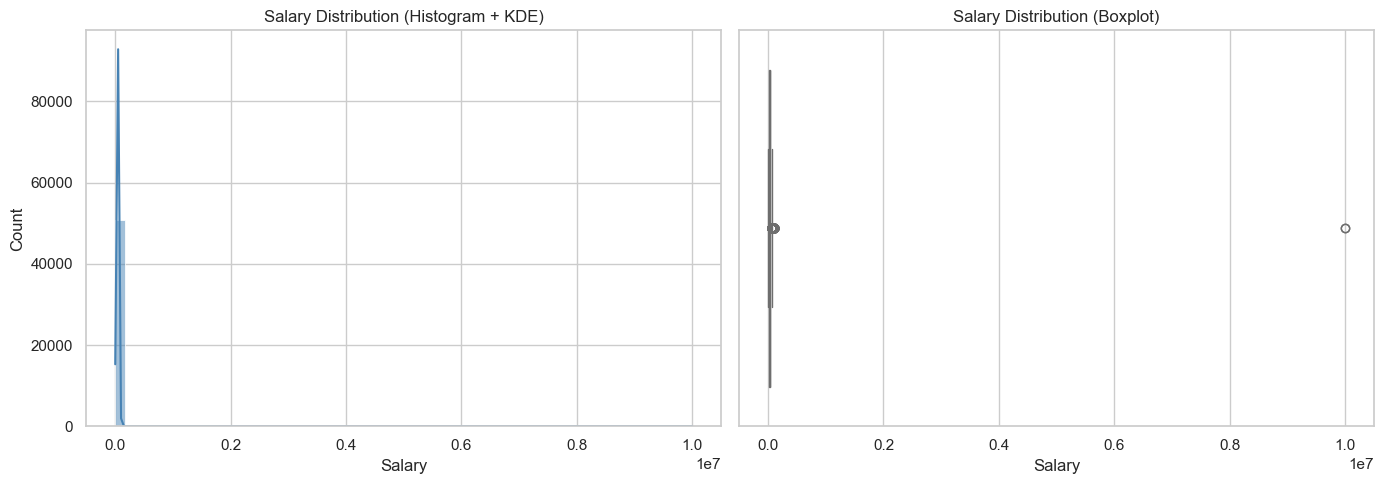

In [16]:
# Visualize salary distribution before audit
fig = Visualizer.visualize_distribution(job_auditor.df["Salary"])
display(fig)

The graph is too ugly because some records have the largerest salary --> that affect negatively the visualization

In [17]:
job_auditor.df[job_auditor.df["Salary"] == job_auditor.df["Salary"].max()]

,Id,Title,Location,Company,ContractType,ContractTime,Category,Salary,OpenDate,CloseDate,SourceName
36294,66934440,Staff Nurse (RGN) Nursing Home Harrow,Harrow,Liquid Personnel Ltd,full_time,non-specified,Healthcare & Nursing Jobs,10000000.0,2012-02-25 12:00:00,2012-03-26 12:00:00,staffnurse.com
49509,71834224,**** Web Designers Required,London,Harvey Nash,full_time,permanent,IT Jobs,10000000.0,2013-11-04 15:00:00,2013-12-04 15:00:00,energygenerationjobs.com


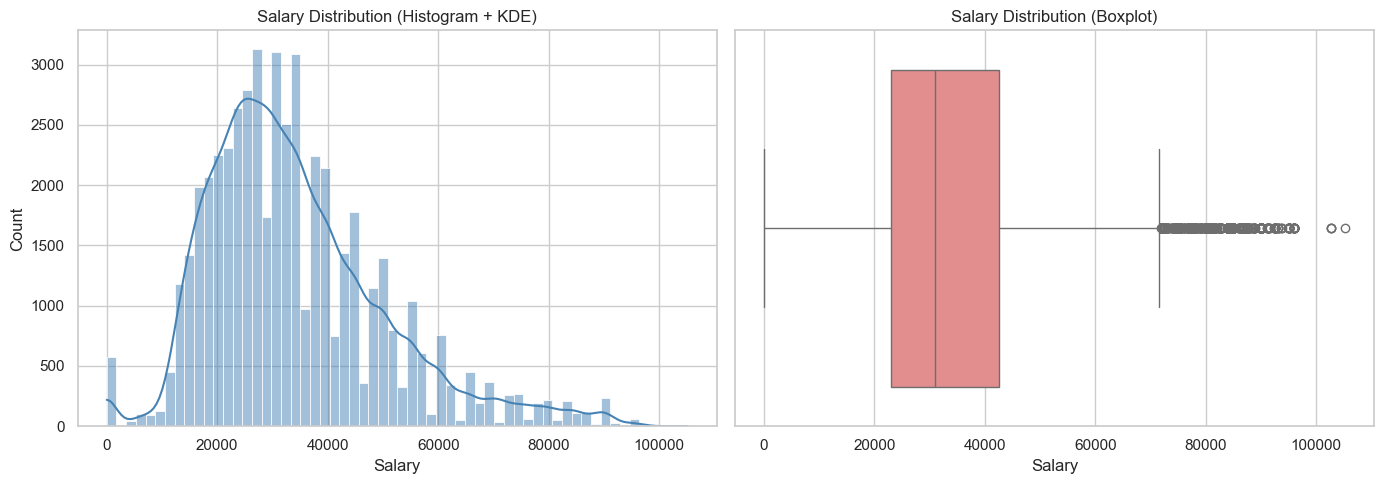

In [18]:
# Remove the record with the largest salary then visualize the distribution
fig = Visualizer.visualize_distribution(job_auditor.df[job_auditor.df["Salary"] < job_auditor.df["Salary"].max()]["Salary"])
display(fig)

**Histogram + KDE**: The distribution is strongly right-skewed. Counts peak around £25k–£35k (roughly in the low‑30k band), with most mass between about £15k and £55k. The density falls off toward higher salaries; a thin bar near £0 suggests a small number of zero (or near‑zero) salaries, which may deserve a separate audit (placeholder vs. true value). Removing only the largest salary does not remove other high earners, so the long right tail remains.

**Boxplot**: The median sits near the low‑30ks; the IQR (middle 50%) spans roughly the low‑20ks to low‑40ks. The whiskers extend further, but many points sit above the upper whisker as individual outliers from the mid‑70ks up toward £100k+. So the chart shows typical salaries in a fairly tight band, with a secondary cluster of high salaries that still look extreme relative to the box—even after excluding the single maximum.

In [19]:
job_auditor_experiment_1 = job_auditor.copy()
job_auditor_experiment_2 = job_auditor.copy()

In [20]:
job_auditor_experiment_1.salary_outlier_mask(method='zscore', verbose=True)
job_auditor_experiment_2.salary_outlier_mask(method='iqr', verbose=True)

[_salary_outlier_mask_zscore]: 2 issues
[_salary_outlier_mask_iqr]: 1835 issues


*Explaination:*

- **Distribution problem**: Salary is strongly right-skewed: most values sit in a middle band (roughly the low–mid tens of thousands), with a long upper tail of high salaries and often a small mass at or near zero. A histogram/boxplot after dropping only Salary.max() still shows skew and many points above the box—removing one point does not change that shape.

- **IQR method (Tukey fences, k = 1.5)**:  On skewed salary data the upper fence usually falls below the top of the tail, so many high salaries (often well over a thousand rows on a full dataset) are adjusted downward to the fence. That materially shrinks the right tail in summaries and plots.

- **Z-score method (|z| > 3, clip to μ ± 3σ)**: Very few salaries exceed |z| > 3 (in a run on the same audited data as above, on the order of a handful, e.g. 2), because the band is so wide. So z-score hardly changes the distribution compared with IQR, even though the raw plot still looks heavy-tailed.

*Conclusion:* IQR method should be applied in that case to remove outlier in `Salary` columns

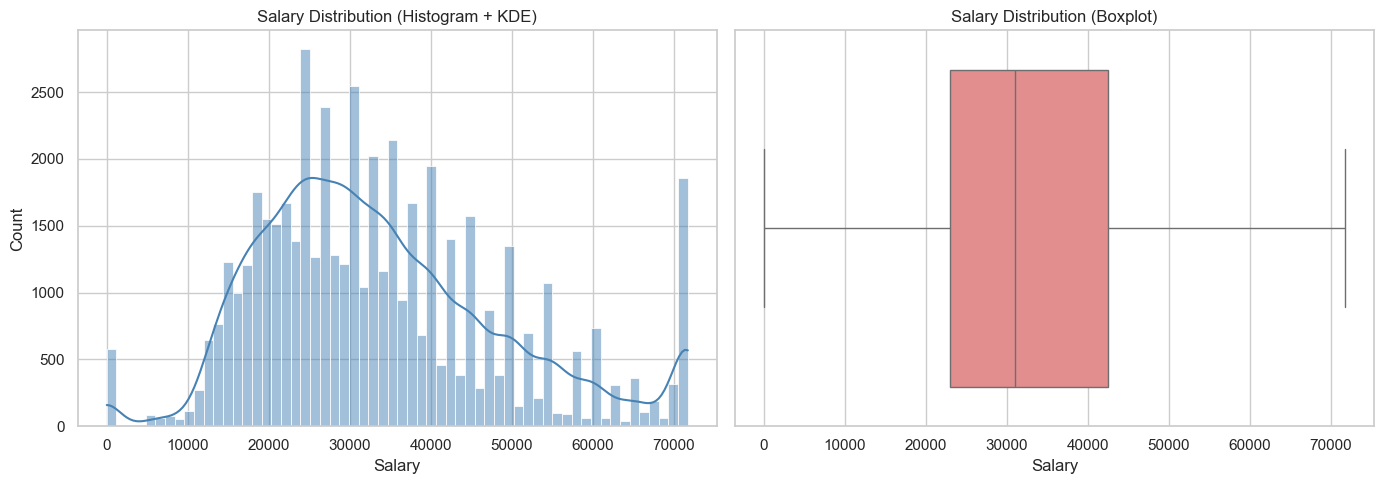

In [21]:
# Distribution after applying IQR method
fig = Visualizer.visualize_distribution(job_auditor_experiment_2.df["Salary"])
display(fig)

In [22]:
job_auditor.salary_outlier_mask(method='iqr', verbose=True)

[_salary_outlier_mask_iqr]: 1835 issues


In [23]:
### 2.2 Next audit step (integrity constraints, outliers, duplicates…)

In [24]:
job_auditor_experiment_3 = job_auditor.copy()

In [25]:
# Take a look at the unique values of the columns ContractType, ContractTime, Category
print(job_auditor_experiment_3.df["ContractType"].unique())
print(job_auditor_experiment_3.df["ContractTime"].unique())
print(job_auditor_experiment_3.df["Category"].unique())

['full_time' 'non-specified' 'part_time']
['permanent' 'contract' 'non-specified']
['PR, Advertising & Marketing Jobs' 'Teaching Jobs' 'Engineering Jobs'
 'Sales Jobs' 'Accounting & Finance Jobs' 'Hospitality & Catering Jobs'
 'IT Jobs' 'Healthcare & Nursing Jobs']


In [26]:
n_unique_location: int = len(job_auditor.df["Location"].unique())
print(n_unique_location)

496


*Analysis*
- **ContractType / ContractTime**: hand-crafted lookup table (_canonical_contract_type / _canonical_contract_time): placeholders (N/A, -) → non-specified, common variants (fulltime, perm) normalized, case-insensitive fallback.
- **Category** — lookup table (_canonical_category): exact match → case-insensitive → curated alias map; unrecognized values are flagged (not silently dropped).
- **Location** — two-step pipeline: _smart_title (title-case preserving UK, apostrophes) + _build_location_cache (rapidfuzz WRatio ≥ 90 against locations appearing ≥ 5 times), applied via a pre-built O(1) cache.
- **SourceName** — intentionally skipped. 

In [27]:
job_auditor_experiment_3.audit_spelling(verbose=True)

[audit_spelling]: 162 issues recorded


In [28]:
# Finally full data processing pipelines with that dataset

def process_data(job_auditor: JobAuditor, verbose: bool = True):
    # Remove the first occurrence of each near-duplicate pair
    rows_to_drop: list = [27912, 45211, 50214] # TODO: Please ensure that the rows to drop are the first occurrence of each near-duplicate pair
    job_auditor.df.drop(index=rows_to_drop, inplace=True)
    job_auditor.df.reset_index(drop=True, inplace=True)

    # Audit missing values
    job_auditor.audit_missing_values(verbose=verbose)

    # Audit integrity constraints
    job_auditor.audit_integrity(verbose=verbose)

    # Audit spelling
    job_auditor.audit_spelling(verbose=verbose)

    # Audit integrity constraints
    job_auditor.salary_outlier_mask(method='iqr', verbose=verbose)

In [29]:
job_auditor_finall = JobAuditor(df)
process_data(job_auditor_finall, verbose=True)

[_impute_smart_salary]: 2380 issues
[_impute_opendate]: 1 issues
[audit_missing_values]: 59531 issues
[audit_integrity]: 5 issues
[audit_spelling]: 162 issues recorded
[_salary_outlier_mask_iqr]: 1835 issues


Verification the output

In [30]:
job_auditor.get_duplicate_df(verbose=True, near_dup_keys=['Title', 'Location', 'Company', 'ContractTime', 'OpenDate', 'Salary', 'SourceName'])

[get_duplicate_df] No duplicates found.


,DuplicateType,Count,Indices
0,Exact row duplicate,0,[]
1,Duplicate Id,0,[]
2,Near-duplicate (Title + Location + Company + C...,0,[]


In [31]:
job_auditor.get_miss_values_df()

,ColumnName,MissingCount,MissingPct
0,Id,0,0.0
1,Title,0,0.0
2,Location,0,0.0
3,Company,0,0.0
4,ContractType,0,0.0
5,ContractTime,0,0.0
6,Category,0,0.0
7,Salary,0,0.0
8,OpenDate,0,0.0
9,CloseDate,0,0.0


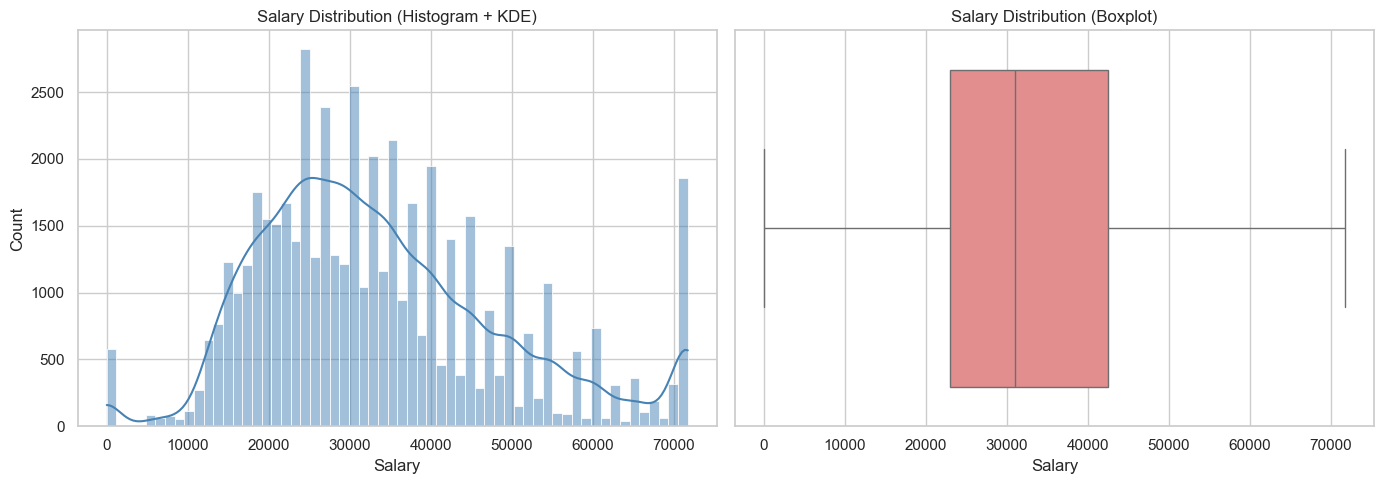

In [32]:
# Distribution after preprocessing
fig = Visualizer.visualize_distribution(job_auditor.df["Salary"])
display(fig)

In [33]:
df_error = pd.DataFrame(job_auditor.errors)

In [34]:
df_error

,indexOfdf,Id,ColumnName,Original,Modified,ErrorType,Fixing
0,13630,71692192,Company,,non-specified,Missing Value,Null/empty 'Company' replaced with 'non-specif...
1,13631,46637478,Company,,non-specified,Missing Value,Null/empty 'Company' replaced with 'non-specif...
2,13632,46636129,Company,,non-specified,Missing Value,Null/empty 'Company' replaced with 'non-specif...
3,13633,66190722,Company,,non-specified,Missing Value,Null/empty 'Company' replaced with 'non-specif...
4,13634,46627775,Company,,non-specified,Missing Value,Null/empty 'Company' replaced with 'non-specif...
...,...,...,...,...,...,...,...
61361,50550,67943680,Salary,93000.0,71750.0,Outlier,Salary outlier (IQR k=1.5) winsorized to fence...
61362,50551,66551345,Salary,75000.0,71750.0,Outlier,Salary outlier (IQR k=1.5) winsorized to fence...
61363,50567,68625014,Salary,85000.0,71750.0,Outlier,Salary outlier (IQR k=1.5) winsorized to fence...
61364,50647,72579028,Salary,90000.0,71750.0,Outlier,Salary outlier (IQR k=1.5) winsorized to fence...


## Saving data
Save the parsed and cleaned data as well as the error list, named as:
- \<student\_id\>_dataset1_solution.csv
- \<student\_id\>_errorlist.csv

In [35]:
student_id = "s4196976"
# code to save output data
job_auditor.df.to_csv(f"output/{student_id}_data_4_solution.csv", index=False)
df_error.to_csv(f"output/{student_id}_errorlist.csv", index=False)

## Summary
Give a short summary and anything you would like to talk about the assessment here.

This assessment focused on turning a large UK job-listings XML file into a clean tabular dataset and documenting every data-quality action. In Task 1, records were parsed into a fixed schema (JobRecord) and loaded into pandas. In Task 2, a single JobAuditor class drove the pipeline: missing values were imputed (including hierarchical salary medians and OpenDate from listing-duration medians by contract fields), contract and category text was normalized, Location was corrected using title-casing plus rapidfuzz matching against frequent place names (avoiding slow, unreliable general spellcheckers), integrity rules and salary/date outliers were applied, and duplicates were inspected—near-duplicates were removed where we chose to keep one row per logical ad. Seaborn plots illustrated how skewed salaries are and how IQR versus z-score outlier handling behaves differently on this data. All changes were logged to a structured error list and the final table and errors were exported under the required filenames.

**The most interesting part was balancing automation with trust**: aggressive spelling tools on Location produced bad “fixes” on real place names, so switching to fuzzy matching against the dataset’s own frequent locations was both faster and more sensible. A limitation is that near-duplicate detection depends on chosen keys (e.g. Title + Company + OpenDate); different keys would surface different pairs. The error list grew large because every imputation and constraint fix was recorded—useful for auditing, but worth summarizing in the report rather than reading row-by-row.